# **Машинное обучение 1, ПМИ ФКН ВШЭ. Бонусное домашнее задание**
##  **Основные методы оценки важности признаков для ML моделей**

В этом домашнем задании вы будете работать с данными о Всемирном отчёте о счастье (World Happiness Report). В качестве теории используйте следующие семинарские материалы: 
- [Основные методы оценки важности признаков для ML моделей](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem11-xai.ipynb);
- [Интерпретация по определению](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem11-xai.pdf).

**Общая информация**

**Дата выдачи:** 04.05.2026

**Дедлайн:** 18.05.2026 23:59MSK

**Оценивание и штрафы**

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимальная оценка за работу - 5 баллов.

Как всегда, сдача после жёсткого дедлайна невозможна. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).


**NB** В этом задании много работ, требующих вывода и размышлений. Куцые выводы, как и неэффективная реализация кода, могут негативно отразиться на оценке.



**Задания сдаются через систему anytask.** Посылка должна содержать:

Ноутбук homework-practice-xai-Username.ipynb
Username - ваша фамилия и имя на латинице именно в таком порядке.


## **Подготовительная часть**

In [27]:
!pip install shap -qU


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
!pip install -qU pyALE


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
!pip install -qU lime fat-forensics[all]


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### **Подготовка данных**

Загрузите датасет по ссылке.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
from sklearn.metrics import mean_squared_error
from sklearn.metrics import pairwise_distances ## hopefully this is no grand sin now 

In [31]:
import urllib.request

url = "https://www.dropbox.com/scl/fi/vn5d4awcg7n307bnewr2x/world-happiness-report-2021-prep-1.csv?rlkey=yk8sn3fblpvtu8iyc02vpryhp&st=cvysdgto&dl=1"
filename = "world-happiness-report-2021-prep.csv"

urllib.request.urlretrieve(url, filename)

('world-happiness-report-2021-prep.csv',
 <http.client.HTTPMessage at 0x137542717b0>)

In [32]:
data_to_work = pd.read_csv('world-happiness-report-2021-prep.csv')

data_to_work.head(5)

,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,7.842,10.775,0.954,72.0,0.949,-0.098,0.186,3.253
1,7.620,10.933,0.954,72.7,0.946,0.030,0.179,2.868
2,7.571,11.117,0.942,74.4,0.919,0.025,0.292,2.839
3,7.554,10.878,0.983,73.0,0.955,0.160,0.673,2.967
4,7.464,10.932,0.942,72.4,0.913,0.175,0.338,2.798


### Примечание про столбец Dystopia + residual.


В World Happiness Report Dystopia - это не реальная страна, а техническая точка отсчёта: гипотетическая страна с минимальными значениями по ключевым факторам (GDP, social support, life expectancy, freedom, generosity, corruption). Её вводят как бенчмарк, чтобы вклады факторов в разложении были неотрицательными.

Столбец `Dystopia + residual` - это  разложения: базовый уровень (оценка жизни в Dystopia) плюс остаточная часть, которую шесть факторов не объясняют для конкретной страны (ошибка/невязка модели). Это не социальный индекс, а слагаемое, которое вместе с вкладами 6 факторов даёт итоговый score.

Иначе говоря, в таблицах WHR:
Score ~ (вклады 6 факторов) + (Dystopia + residual).

### Поехали дальше

In [33]:
X = data_to_work.drop('Ladder score', axis=1)
y = data_to_work['Ladder score']

Для обучения будем использовать два способа масштабирования - `MinMaxScaler` и `StandardScaler`.

In [34]:
feature_names = list(X.columns)

# Выберем признак для анализа
feature_idx = 1
feature_name = X.columns[feature_idx]

print(f'FEATURE TO ANALYZE: {feature_name}')

FEATURE TO ANALYZE: Social support


In [35]:
# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 1
sc_minmax = MinMaxScaler()
X_train_sc_minmax = sc_minmax.fit_transform(X_train)
X_test_sc_minmax = sc_minmax.transform(X_test)

# 2
sc_standard = StandardScaler()
X_train_sc_standard = sc_standard.fit_transform(X_train)
X_test_sc_standard = sc_standard.transform(X_test)

### **Задание 1. (0.5 балла)**
- Обучите 6 моделей:
  -  линейную регрессию (`LinearRegression`) на двух вариантах данных;
  - Lasso регрессию (`Lasso`) на двух вариантах данных;
  - градиентный бустинг (`GradientBoostingRegressor`) на двух вариантах данных;
- Выведите MSE и RMSE моделей.
- Зафиксируйте выводы.

> Цель задания - увидеть, какие модели чувствительны к масштабу признаков (Lasso), а какие почти инвариантны (LR/деревья), и почему это важно для интерпретации.


**NB:** Для бустингов ограничьте глубину до 5.

In [36]:
results = {}

datasets = {
    'minmax': (X_train_sc_minmax, X_test_sc_minmax), 
    'standard': (X_train_sc_standard, X_test_sc_standard)
}

def get_models():
    return {
        'lr': LinearRegression(), 
        'lasso': Lasso(alpha=0.01, random_state=42), 
        'gb': GradientBoostingRegressor(max_depth=5, random_state=42)
    }

for scale_name, (X_train, X_test) in datasets.items():
    print(f'{scale_name}')
    models = get_models()
    
    for model_prefix, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mse = mean_squared_error(y_test, y_pred) 
        rmse = np.sqrt(mse)

        key = f'{model_prefix}_{scale_name}'
        
        results[key] = (model, mse, rmse)

        print(f'{model_prefix};  MSE: {mse:.6f}, RMSE: {rmse:.6f}')

minmax
lr;  MSE: 0.000001, RMSE: 0.000992
lasso;  MSE: 0.007493, RMSE: 0.086562
gb;  MSE: 0.153085, RMSE: 0.391261
standard
lr;  MSE: 0.000001, RMSE: 0.000992
lasso;  MSE: 0.000344, RMSE: 0.018556
gb;  MSE: 0.153073, RMSE: 0.391246


## **1. Интерпретация по определению**

Воспользуемся встроенными важностями в моделях. Для бустинга — усредненная важность по деревьям, для регрессий — коэффициенты.

### **Задание 2. (0.25 балла)**
- Постройте график (любой, на ваш выбор), позволяющий визуально оценить и сравнить коэффициенты по парам моделей:
  - Модель и `StandardScaler` vs Модель и `MinMaxScaler`
- Зафиксируйте выводы по каждой из пар графиков.

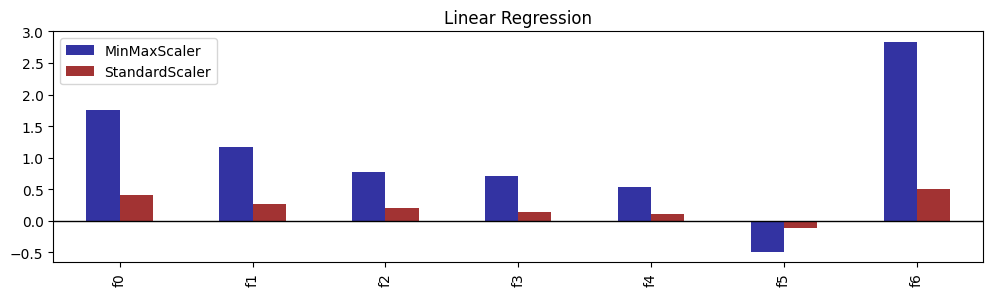

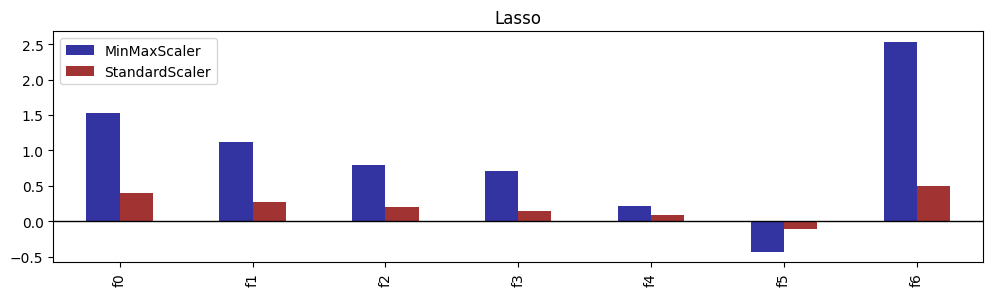

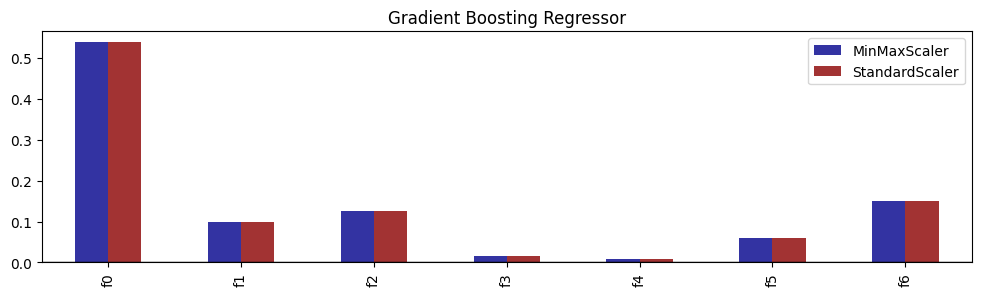

In [37]:
lr_minmax = results['lr_minmax'][0]
lasso_minmax = results['lasso_minmax'][0]
gb_minmax = results['gb_minmax'][0]

lr_std = results['lr_standard'][0]
lasso_std = results['lasso_standard'][0]
gb_std = results['gb_standard'][0]

if hasattr(X_train_sc_minmax, 'columns'):
    features = X_train_sc_minmax.columns
else:
    features = [f'f{i}' for i in range(X_train_sc_minmax.shape[1])]

def plot_coefficients(model_name, coef_minmax, coef_std):
    df = pd.DataFrame({
        'MinMaxScaler': coef_minmax,
        'StandardScaler': coef_std
    }, index=features)
    
    fig, ax = plt.subplots(figsize=(12, 3))
    df.plot(kind='bar', ax=ax, alpha=0.8, color=['darkblue', 'darkred'])
    
    plt.title(f'{model_name}')
    plt.axhline(0, color='black', linewidth=1)
    plt.show()

plot_coefficients('Linear Regression', lr_minmax.coef_, lr_std.coef_)
plot_coefficients('Lasso', lasso_minmax.coef_, lasso_std.coef_)
plot_coefficients('Gradient Boosting Regressor', gb_minmax.feature_importances_, gb_std.feature_importances_)

**Ваш вывод здесь:**

На первом графике наблюдаются значительные расхождения в значениях коэффициентов при использовании MinMaxScaler и StandardScaler . В линейных моделях вес признака показывает изменение целевой переменной при изменении предиктора на "одну единицу". Поскольку скейлеры задают совершенно разные метрики для единицы, коэффициенты подстраиваются обратно пропорционально масштабу данных. Это показывакет, что в линейной регрессии абсолютные значения весов нельзя интерпретировать как истинную важность признаков без предварительной стандартизации дисперсии.

**Ваш вывод здесь:**

На втором графике, в отличие от первого, здесь мы видим, что некоторые признаки полностью зануляются, причем этот процесс происходит по-разному для разных скейлеров. Штраф в Lasso накладывается на абсолютную величину коэффициентов. При использовании MinMaxScaler дисперсии признаков не выровнены, поэтому модель вынуждена применять большие коэффициенты к признакам с малым диапазоном, что делает их главной мишенью для штрафа и несправедливого обнуления. StandardScaler центрирует данные и уравнивает дисперсии, обеспечивая более корректную работу механизма отбора признаков.

**Ваш вывод здесь:**

Третий график демонстрирует абсолютное совпадение важности признаков для обоих методов масштабирования. Это  подтверждает  свойство алгоритмов на основе деревьев решений: их инвариантность к монотонным преобразованиям. Масштабирование признаков лишь сдвигает численное значение порога разбиения в узлах деревьев, но никак не меняет саму структуру дерева, порядок сортировки объектов и итоговый прирост информации.

### **Задание 3. (0.25 балла)**
Вернитесь к графику линейной регрессии. Очевидно, что коэффициенты одной модели связаны с коэффициентами другой. Как перейти от одних к другим? Реализуйте это в коде, как для свободного члена, так и для самих коэффициентов.

> Идея: коэффициенты линейной модели можно сравнивать как важности только при фиксированном масштабе. Вывод формулы перехода - способ строго показать, что коэффициенты меняются предсказуемо и не являются абсолютной важностью.

**Ваши теоретические выкладки здесь:**

$X$, матрица исходных признаков.

Формула `MinMaxScaler`: 
$$X_{mm} = X \cdot S_{mm} + M_{mm}$$
$S_{mm}$ это `scale_`, а $M_{mm}$ сдвиг (мы отметим как `min_` ).

Формула `StandardScaler`: 
$$X_{std} = \frac{X - \mu}{\sigma} \implies X = X_{std} \cdot \sigma + \mu$$
$\mu$ это среднее (`mean_`), а $\sigma$  это стандартное отклонение (`scale_` в StandardScaler).

Подставим выраженный $X$ из формулы StandardScaler в формулу MinMaxScaler:
$$X_{mm} = (X_{std} \cdot \sigma + \mu) \cdot S_{mm} + M_{mm}$$
$$X_{mm} = X_{std} \cdot \sigma \cdot S_{mm} + (\mu \cdot S_{mm} + M_{mm})$$

Теперь запишем уравнение линейной регрессии, обученной на данных после MinMaxScaler:
$$\hat{y} = X_{mm} \cdot w_{mm} + b_{mm}$$

Подставляем наше выражение для $X_{mm}$:
$$\hat{y} = (X_{std} \cdot \sigma \cdot S_{mm} + \mu \cdot S_{mm} + M_{mm}) \cdot w_{mm} + b_{mm}$$

$$\hat{y} = X_{std} \cdot (w_{mm} \cdot \sigma \cdot S_{mm}) + \sum_{i} w_{mm}^{(i)} (\mu^{(i)} \cdot S_{mm}^{(i)} + M_{mm}^{(i)}) + b_{mm}$$

Сравнивая полученное выражение со стандартным уравнением регрессии $\hat{y} = X_{std} \cdot w_{std} + b_{std}$, мы получаем нужные формулы перехода:

Веса: $$w_{std} = w_{mm} \cdot \sigma \cdot S_{mm}$$

Свободный член: $$b_{std} = b_{mm} + \sum_{i} w_{mm}^{(i)} (\mu^{(i)} \cdot S_{mm}^{(i)} + M_{mm}^{(i)})$$

В итоге коэффициенты линейной модели меняются в зависимости от параметров нормализации. Это показывает, что сами по себе веса не являются абсолютной мерой важности признака, а их значения имеют смысл только в привязке к конкретному масштабу данных.

In [38]:
S_mm = sc_minmax.scale_
M_mm = sc_minmax.min_

sigma = sc_standard.scale_
mu = sc_standard.mean_

lr_minmax = results['lr_minmax'][0]

w_mm = lr_minmax.coef_
b_mm = lr_minmax.intercept_

coef_std = w_mm * sigma * S_mm
intercept_std = b_mm + np.sum(w_mm * (mu * S_mm + M_mm))

assert round(intercept_std, 4) == round(results['lr_standard'][0].intercept_, 4)
assert all(np.round(coef_std, 4) == np.round(results['lr_standard'][0].coef_, 4))

## **1. Plot-based методы**

Рассмотрев тонкости работы с масштабированием, поработаем с plot-based методами. Оставьте теперь для анализа линейную регрессию и бустинг, обученные на MinMaxScaler.

In [39]:
lr_minmax = results['lr_minmax'][0]
gb_minmax = results['gb_minmax'][0]

### **1. 1. ICE**

**Построение:**

1. Зафиксируем множество $X_{test}$ и некоторый признак $j$. Пусть  $j$ имеет $m$ уникальных значений $[j_1, j_2, ..., j_m]$.

2. Исходный датасет  $X_{test}$ дублируем  $m$ раз: $$X'_1, X'_2, ..., X'_m,$$ так, что для датасета $X'_i$ значение признака $j$ есть $j_i$;

3. На каждом $X'_i$ рассчитываем прогноз модели $f(X'_i)$&

4. На графике строим линии для каждого объекта, показывающие как прогноз (ось $y$) меняется при изменении признака (ось $x$);

### **Задание 4. (0.5 балла)**

Мы знаем, что признаки модели масштабированы определенным образом. Минимум каждого признака равен 0, максимум 1. Что будет с моделями, если признаки выйдут из диапазона?
- Работая с тем же признаком, изучите его **исходные** минимум и максимум. Сделайте искусственный диапазон из 20 точек, равный $[max, 3*max]$.
- На полученном диапазоне постройте ICE для обеих моделей. ICE стройте собственноручно, без использования sklearn.
- Зафиксируйте выводы


c:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarni

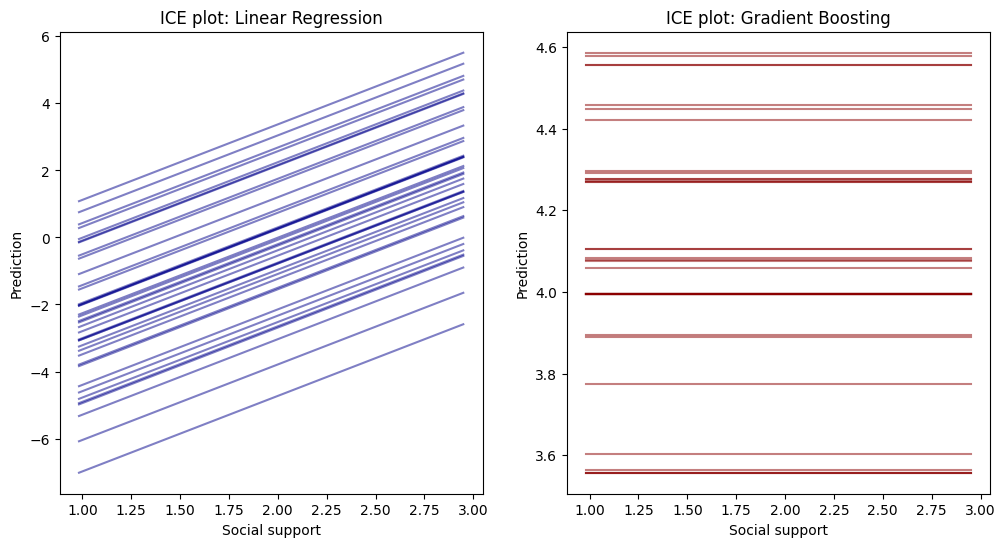

In [40]:
original_min = X[feature_name].min()
original_max = X[feature_name].max()

artificial_grid = np.linspace(original_max, 3 * original_max, 20) 

ice_predictions_lr = []
ice_predictions_gb = []

feature_index = X.columns.get_loc(feature_name)

for val in artificial_grid: 
    X_temp = X_test.copy()
    X_temp[:, feature_index] = val 

    X_temp_sc = sc_minmax.transform(X_temp)

    ice_predictions_lr.append(lr_minmax.predict(X_temp_sc))
    ice_predictions_gb.append(gb_minmax.predict(X_temp_sc))

ice_predictions_gb = np.array(ice_predictions_gb).T 
ice_predictions_lr = np.array(ice_predictions_lr).T 

fig, axes = plt.subplots(1,2, figsize=(12,6))

for i in range(ice_predictions_lr.shape[0]):
    axes[0].plot(artificial_grid, ice_predictions_lr[i], color='darkblue', alpha = 0.5)

axes[0].set_title('ICE plot: Linear Regression')
axes[0].set_xlabel(feature_name)
axes[0].set_ylabel('Prediction')

for i in range(ice_predictions_gb.shape[0]):
    axes[1].plot(artificial_grid, ice_predictions_gb[i], color = 'darkred', alpha = 0.5)

axes[1].set_title('ICE plot: Gradient Boosting')
axes[1].set_xlabel(feature_name)
axes[1].set_ylabel('Prediction')

plt.show()


**Ваш вывод здесь:**

Линейная регрессия предполагает линейные отношения, и при умножении признаков на 3, предсказания линейно растут. В силу науры этой модели, она экстраполирует данный тренд до бесконечности (если бы мы продолжлили его умножать).

Модели решаюших деревьев не могут экстраполировать сверх тех данных на которых они были обучены, любое значение выше максимума из обучения упадет на наиправешую вершину дерева. В итоге мы наблюдаем прямые линии. 

(меня столько начальных warnings испугали, но это ок, хоть и не красиво)

### **1. 2. PDP**

Теперь посмотрим на усредненнуе влияние признака.
### **Задание 5. (0.25 балла)**

- Усредните ICE по обеим моделям, используя PDP из sklearn.
- Сделайте выводы.


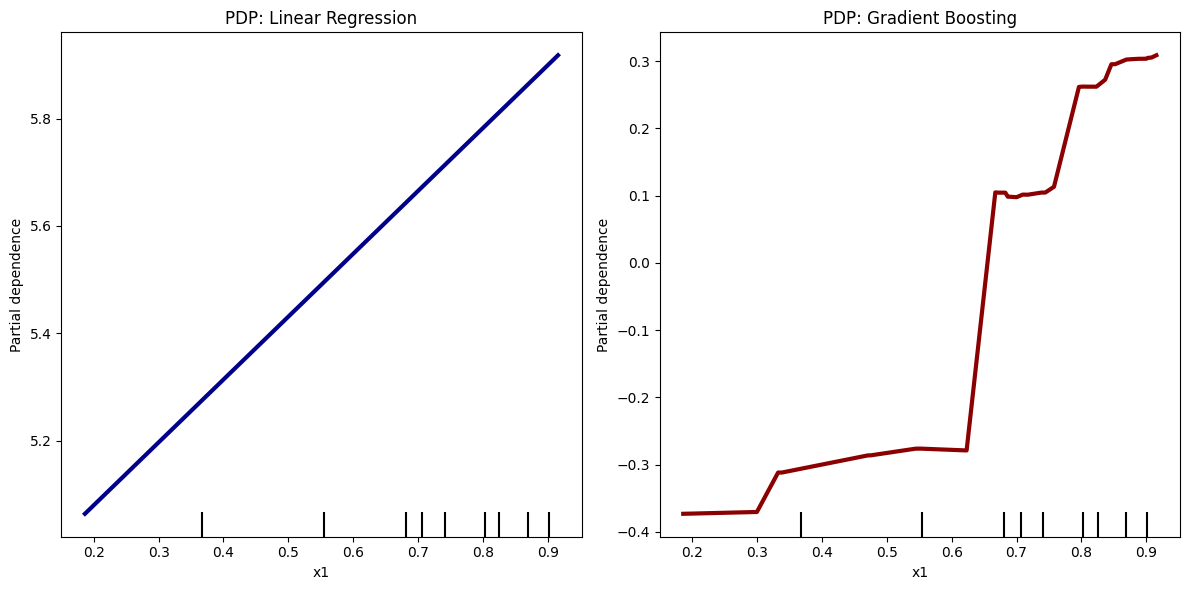

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

PartialDependenceDisplay.from_estimator(
    estimator=lr_minmax,
    X=X_test_sc_minmax,
    features=[feature_index],
    kind='average',
    ax=axes[0],
    line_kw={"color": "darkblue", "linewidth": 3}
)
axes[0].set_title(f'PDP: Linear Regression')
axes[0].set_xlabel(feature_name)
axes[0].set_ylabel('Average Prediction')

PartialDependenceDisplay.from_estimator(
    estimator=gb_minmax,
    X=X_test_sc_minmax,
    features=[feature_index],
    kind='average',
    ax=axes[1],
    line_kw={"color": "darkred", "linewidth": 3}
)
axes[1].set_title(f'PDP: Gradient Boosting')
axes[1].set_xlabel(feature_name)
axes[1].set_ylabel('Average Prediction')

plt.tight_layout()
plt.show()


**Ваш вывод здесь:**

1. **Линейная регрессия:** Получаем прямую линию, что ожидаемо, линейная модель по своей природе предполагает, что признак оказывает строго линейное воздействие на целевую переменную, независимо от значений других признаков.
2. **Градиентный бустинг:** Имеет ступенчатый вид. Это связано с архитектурой деревьев решений, которые разбивают признак на интервалы и предсказывают константу в каждом листе.


Обе модели согласны в том, что рост ВВП ведет к увеличению уровня счастья. Однако бустинг улавливает важную нелинейность реального мира, тут это возможно эффект убывающей отдачи. На графике видно, что при достижении высоких значений ВВП рост счастья замедляется. Линейная регрессия этот эффект уловить не способна и просто продолжает наращивать прогноз.

### **1. 3. Accumulated Local Effects (ALE)**

Заключительный из основных графических методов — ALE. Ради практики построим и его.

### **Задание 6. (0.5 балла)**

- Постройте ALE по обеим моделям, используя pyALE. (0.15)
- Подберите размер сетки так, чтобы получить доверительные интервалы. (0.05)
- Проанализируйте полученный график. Каковы получились ДИ? Почему они различны для моделей? (0.3)

> Важно: сетку значений строим в исходных единицах признака, но перед подачей в модель применяем тот же scaler, на котором обучение.

PyALE._ALE_generic:INFO: Continuous feature detected.
c:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
PyALE._ALE_generic:INFO: Continuous feature detected.
c:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
c:\Users\danie\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


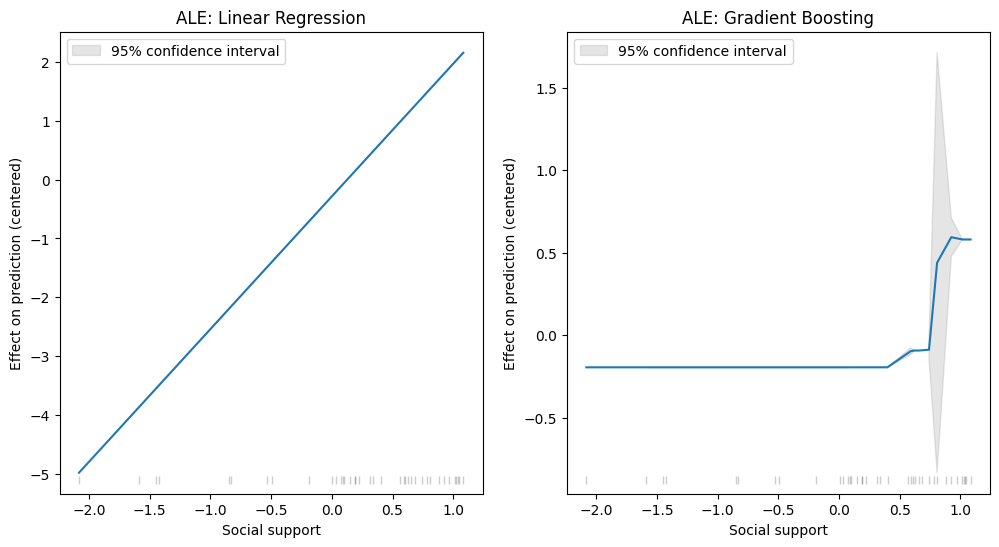

In [42]:
from PyALE import ale

class ScaledPredictor: 
    def __init__(self, model, scaler) -> None:
        self.model = model 
        self.scaler = scaler
    
    def predict(self, X_unscaled):
        X_scaled = self.scaler.transform(X_unscaled.values if isinstance(X_unscaled, pd.DataFrame) else X_unscaled)
        return self.model.predict(X_scaled)
    
lr_wrapper = ScaledPredictor(lr_minmax, sc_minmax)
gb_wrapper  = ScaledPredictor(gb_minmax, sc_minmax)

optimal_grid_size = 20 

fig, axes = plt.subplots(1,2, figsize= (12, 6)) 

ale_lr = ale(
    X=pd.DataFrame(X_test, columns=X.columns),  
    model=lr_wrapper, 
    feature=[feature_name], 
    grid_size=optimal_grid_size, 
    include_CI=True,
    fig=fig,
    ax=axes[0]
)

axes[0].set_title(f'ALE: Linear Regression')

ale_gb = ale(
    X=pd.DataFrame(X_test, columns=X.columns), 
    model=gb_wrapper, 
    feature=[feature_name], 
    grid_size=optimal_grid_size, 
    include_CI=True,
    fig=fig,
    ax=axes[1]
)
axes[1].set_title(f'ALE: Gradient Boosting')

plt.show()


**Ваши выводы здесь:**

**Линейная регрессия**

Влияние ВВП на уровень счастья в линейной модели выглядит как прямая линия в силу линейного влияния признака на таргет. Если посмотреть на доверительный интервал (закрашенную область), то его здесь вообще нет, он просто схлопнулся в эту самую прямую. 

**Градиентный бустинг**

У бустинга график усредненного влияния получился нелинейным и ступенчатым. Доверительный интервала здесь довольно заметен. Ансамбли деревьев умеют находить сложные взаимодействия между признаками. Это значит, что эффект от небольшого роста ВВП для конкретной страны может сильно зависеть от других ее параметров. Поэтому даже для стран с примерно одинаковым исходным ВВП реакция модели на его изменение будет отличаться. Закрашенная область вокруг кривой как раз визуализирует этот разброс и неоднородность влияния признака.

## **2. Permutation importances**

Практикуем ещё один метод.
### **Задание 7. (0.25 балла)**

- Постройте Permutation importances по обеим моделям, используя sklearn
- Поэкспериментируйте с числом перестановок. (0.05)
- Проанализируйте полученные коэффициенты. Как они меняются от количества перестановок? Как меняются std коэффициентов? Зафиксируйте выводы. (0.20)

Linear Regression


,n_repeats,mean_importance,mean_std
0,5,0.166503,0.029487
1,10,0.174887,0.032792
2,30,0.176546,0.029293
3,50,0.175608,0.029223
4,100,0.179903,0.030287



 Gradient Boosting


,n_repeats,mean_importance,mean_std
0,5,0.124330,0.033871
1,10,0.126972,0.038674
2,30,0.132182,0.037875
3,50,0.133778,0.037353
4,100,0.137388,0.038214


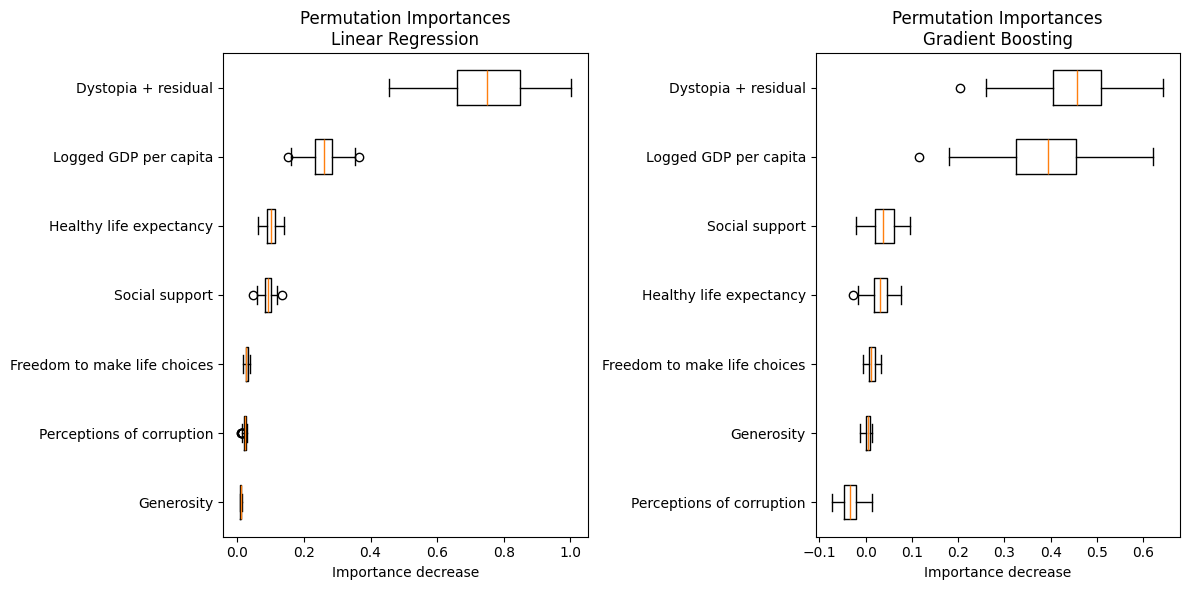

In [43]:
from sklearn.inspection import permutation_importance

n_repeats_list = [5, 10, 30, 50, 100]

stats_lr = []
stats_gb = []

final_pi_lr = None
final_pi_gb = None

for n in n_repeats_list:
    pi_lr = permutation_importance(lr_minmax, X_test_sc_minmax, y_test, n_repeats=n, random_state=42, n_jobs=-1)
    pi_gb = permutation_importance(gb_minmax, X_test_sc_minmax, y_test, n_repeats=n, random_state=42, n_jobs=-1)
    
    stats_lr.append({
        'n_repeats': n, 
        'mean_importance': np.mean(np.abs(pi_lr.importances_mean)), 
        'mean_std': np.mean(pi_lr.importances_std)
    })
    
    stats_gb.append({
        'n_repeats': n, 
        'mean_importance': np.mean(np.abs(pi_gb.importances_mean)), 
        'mean_std': np.mean(pi_gb.importances_std)
    })
    
    if n == max(n_repeats_list):
        final_pi_lr = pi_lr
        final_pi_gb = pi_gb

print('Linear Regression')
display(pd.DataFrame(stats_lr))

print('\n Gradient Boosting')
display(pd.DataFrame(stats_gb))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sorted_idx_lr = final_pi_lr.importances_mean.argsort()
sorted_idx_gb = final_pi_gb.importances_mean.argsort()

axes[0].boxplot(
    final_pi_lr.importances[sorted_idx_lr].T,
    vert=False,
    tick_labels=X.columns[sorted_idx_lr]
)
axes[0].set_title(f'Permutation Importances\nLinear Regression')
axes[0].set_xlabel('Importance decrease')

axes[1].boxplot(
    final_pi_gb.importances[sorted_idx_gb].T,
    vert=False,
    tick_labels=X.columns[sorted_idx_gb]
)
axes[1].set_title(f'Permutation Importances\nGradient Boosting')
axes[1].set_xlabel('Importance decrease')

fig.tight_layout()
plt.show()

Почему признаки расположены в разном порядке?

Признаки на оси Y отсортированы независимо для каждого графика снизу вверх, от наименее важных к самым важным, просто на основе их среднего значения важности. Порядок получается разным из-за того, что линейная регрессия и градиентный бустинг обучаются на абсолютно разных принципах. Линейная регрессия ищет только строгие прямые связи. Градиентный бустинг, напротив, строит сложные деревья решений, которые ищут оптимальные сплиты и нелинейные взаимодействия.

Что это за кружочки по краям?

Эти кружочки на краях графиков это статистические выбросы.

**Ваши выводы здесь:**

По мере увеличения количества перестановок средние значения важности признаков становятся более стабильными и плавными, сходясь к своим истинным математическим ожиданиям. При малом числе итераций оценка сильно подвержена случайности, из-за чего стандартное отклонение получается довольно большим, а границы усов скачут.

Когда мы увеличиваем количество перестановок до 30 или 50, дисперсия оценки падает. Ящики на графиках становятся уже, разброс значений уменьшается, а сама оценка важности становится надежнее. При этом приоритеты не меняются. Рост числа итераций просто дает нам больше уверенности в этих результатах и позволяет четче отделить нормальные отклонения от редких статистических выбросов. 

### **Задание 8. (0.5 балла)**

Идея перестановочной важности представляет собой частный случай важности при помощи внесения **возмущений** в признак. Возмущения могут быть разных видов:

- внесение случайного шума;
- зануление признака (удобно для изображений);
- сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели;

В этом задании попробуем построить оценку на основе сдвига к базовому значению траектории. Примем за базовое значение медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:

$$x_j^{(\beta)}=(1-\beta)x_j+\beta b_j$$

где $b_j$ – медиана признака. Важность будем оценивать как изменение MSE по тест-данным.

1. Реализуйте это возмущение. Как меняются важности при разных $\beta$?
2. Постройте bar-график и сравните ранжирование с **permutation importance**. При сравнении, анализируйте только числовые признаки.


Для регрессии эффект очевиден, поэтому эту окклюзию оценивайте только для бустинга.
**Подсказка:**

1. Выберите базовые значения $x_j$ как **медианы по train** (базовые значения обозначим за $b_j$);
2. На тренировочном наборе данных для каждого признака $j$ замените столбец $x_j$ на $x^{(\beta)}_j=(1-\beta)x_j+\beta b_j$ при разных $\beta$, равных $[0.2, 0.5, 1]$.
3. Посчитайте $\Delta L_j = \text{MSE}(y,\hat y^{(\beta)}_j)-\text{MSE}(y,\hat y)$. Чем больше $\Delta L_j$, тем важнее признак.



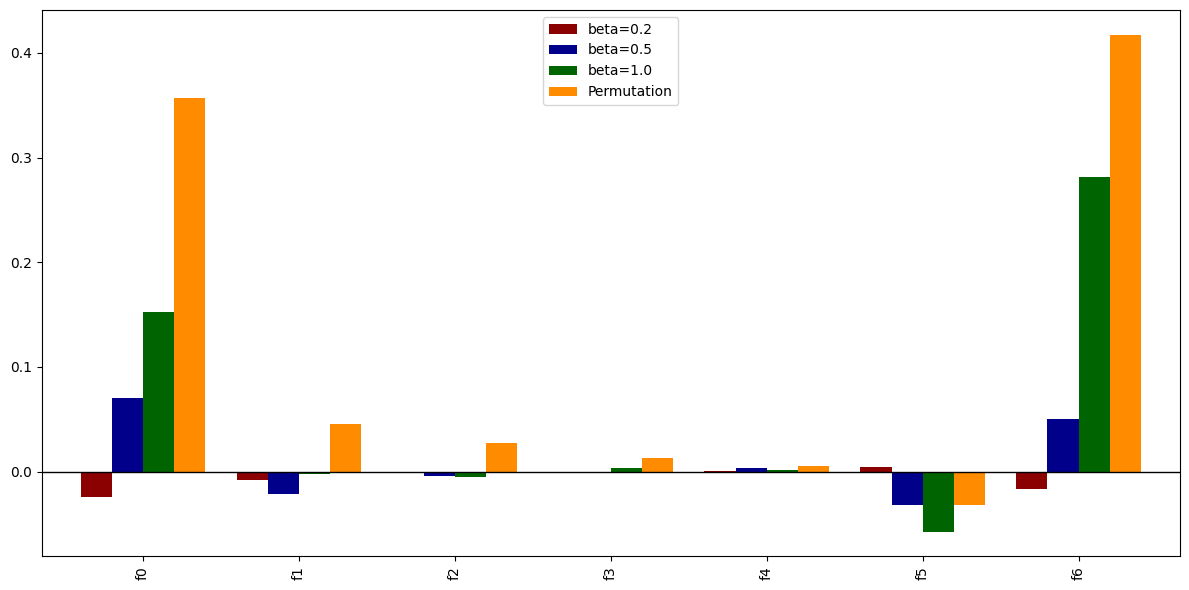

In [44]:
def occlusion_importance(model, X_train, X_test, y_test, beta):
    baseline_mse = mean_squared_error(y_test, model.predict(X_test))
    importances = []
    
    for j in range(X_test.shape[1]):
        b_j = np.median(X_train[:, j])
        X_test_mod = X_test.copy()
        X_test_mod[:, j] = (1 - beta) * X_test[:, j] + beta * b_j
        
        mse_mod = mean_squared_error(y_test, model.predict(X_test_mod))
        importances.append(mse_mod - baseline_mse)
        
    return np.array(importances)

betas = [0.2, 0.5, 1.0]
occlusion_results = {}

for b in betas:
    occlusion_results[f'beta={b}'] = occlusion_importance(
        gb_minmax, 
        X_train_sc_minmax, 
        X_test_sc_minmax, 
        y_test, 
        b
    )

perm_imp = permutation_importance(
    gb_minmax, 
    X_test_sc_minmax, 
    y_test, 
    n_repeats=10, 
    random_state=42, 
    scoring='neg_mean_squared_error'
)

df_importances = pd.DataFrame(occlusion_results, index=features)
df_importances['Permutation'] = perm_imp.importances_mean

fig, ax = plt.subplots(figsize=(12, 6))
df_importances.plot(kind='bar', ax=ax, width=0.8, color=['darkred', 'darkblue', 'darkgreen', 'darkorange'])
plt.axhline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

**Ваши выводы здесь:**

Видно, что увеличивая бету от 0.2 до 1.0, мы всё сильнее схлопываем реальные значения признака, приближая их к медиане обучающей выборки. Естественно, чем сильнее мы искажаем данные, тем больше начинает ошибаться наша модель. На графике видно, что столбцы для беты, равной единице, ожидаемо самые высокие среди всех вариантов окклюзии. Это логично так как при  $\beta=1$ мы затираем всю уникальную информацию о признаке, превращая его в константу, из-за чего модель лишается важного куска данных для построения прогноза и её ошибка возрастает.

Если же сравнить самую жесткую окклюзию ($\beta=1$) со стандартной перестановкой (Permutation), то можно заметить, что oба метода уверенно отдают первые последние места одним и тем же признакам. Однако значения падения метрики отличаются. Кажктся что фишка в том, что метод перестановок перемешивает данные, создавая иногда совершенно неестественные комбинации. От такого шума модель ошибается сильнее. А вот замена на медиану, это просто подсовывание модели некого среднего, безопасного» значения. Деревья бустинга переваривают такую константу чуть спокойнее, чем полный рандом, поэтому столбики Permutation для топовых признаков обычно выстреливают выше. 

## **3. SHAP**

Теперь проведем локальный анализ, используя SHAP и LIME. Но для shap также построим глобальные графики.

### **Задание 9. (0.5 баллa)**
- Постройте два глобальных графика, используя SHAP. Как один из них обязательно используйте `force`, как другой — выберите любой из документации. (0.25 балл)
- Проанализируйте важность признаков в обоих алгоритмах.(0.25 балл)

**NB:** Для линейного алгоритма используйте masker=`shap.maskers.Independent(data=X_train_sc)`. Он имитирует отсутствие признака

C:\Users\danie\AppData\Local\Temp\ipykernel_26088\38822990.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_lr, X_test_sc_minmax, feature_names=features, show=False)


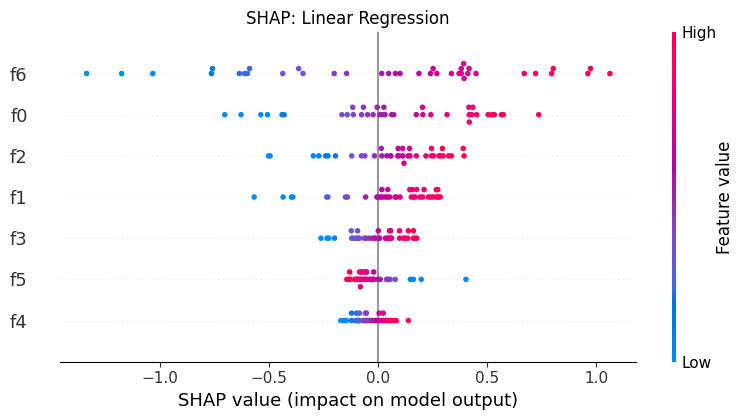

C:\Users\danie\AppData\Local\Temp\ipykernel_26088\38822990.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_gb, X_test_sc_minmax, feature_names=features, show=False)


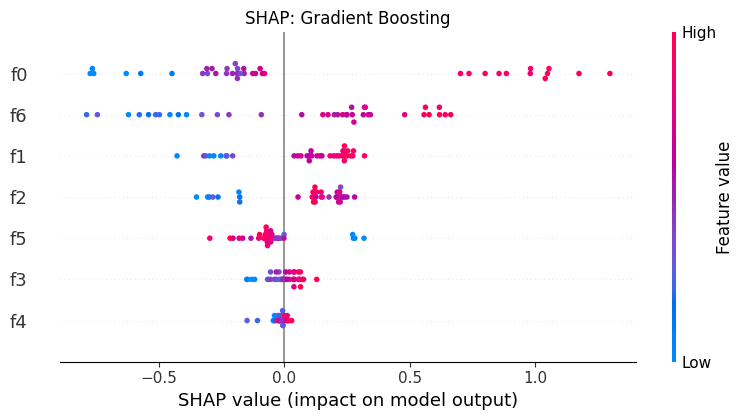

In [45]:
import shap

shap.initjs()

masker = shap.maskers.Independent(data=X_train_sc_minmax)
explainer_lr = shap.LinearExplainer(lr_minmax, masker=masker)
shap_values_lr = explainer_lr.shap_values(X_test_sc_minmax)

explainer_gb = shap.TreeExplainer(gb_minmax)
shap_values_gb = explainer_gb.shap_values(X_test_sc_minmax)

plt.figure()
shap.summary_plot(shap_values_lr, X_test_sc_minmax, feature_names=features, show=False)
plt.title("SHAP: Linear Regression")
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(shap_values_gb, X_test_sc_minmax, feature_names=features, show=False)
plt.title("SHAP: Gradient Boosting")
plt.tight_layout()
plt.show()

display(shap.force_plot(explainer_lr.expected_value, shap_values_lr, X_test_sc_minmax, feature_names=features))

display(shap.force_plot(explainer_gb.expected_value, shap_values_gb, X_test_sc_minmax, feature_names=features))

 **Ваш вывод здесь:**

На первых двух графиках видна разница алгоритмов. Каждая точка здесь, это конкретная страна, а её цвет показывает исходное значение признака (красный высокое, синий низкое). Положение на оси X показывает, как сильно этот признак сдвинул прогноз модели от базового уровня счастья.

У линейной регрессии все предельно просто и монотонно. Красные точки лежат строго с одной стороны от нуля, а синие — с другой. Чем выше ВВП, тем больше счастья, и никаких исключений модель не делает.

У градиентного бустинга на первое место снова вырвалась социальная поддержка (как это было в предыдущих заданиях). Во-вторых, точки образуют более толстые и смешанные скопления. Это значит, что бустинг улавливает нелинейность и взаимодействия: например, средний уровень какого-то признака может давать совершенно разный вклад в итоговое счастье в зависимости от других факторов (именно поэтому цвета могут немного перемешиваться ближе к центру).

На большом сдвоенном графике показана глобальная картина предсказаний сразу для всей выборки (по оси X расположены объекты, а по оси Y значение прогноза и вклады фичей).

Для линейной регрессии модель складывает признаки умноженные на постоянные веса, переходы между разными предсказаниями получаются относительно более плавными и предсказуемыми.

Для бустинга, деревья решений дробят объекты на разные сегменты на основе сложных условий, поэтому влияние признаков может резко меняться от одной группы стран к другой.

## **Локальное объяснение.**

### **Задание 10. (0.25 балла)**
- Постройте локальный график с SHAP для объекта с индексом 7 на обеих моделях и сделайте выводы.

In [46]:
idx = 7

display(shap.force_plot(
    explainer_lr.expected_value, 
    shap_values_lr[idx], 
    X_test_sc_minmax[idx], 
    feature_names=features
))

display(shap.force_plot(
    explainer_gb.expected_value, 
    shap_values_gb[idx], 
    X_test_sc_minmax[idx], 
    feature_names=features
))

**Ваш вывод здесь:**

Видно, что модели выдали разные прогнозы для одной и той же страны. Главная причина такой разницы лежит в том, мне кажется, что для f1 модели сделали разную оценку.

В линейной модели этот признак меньше и тянет итоговый прогноз вниз, так как алгоритм оценивает его строго линейно и изолированно от других факторов. А вот в бустинге этот же самый показатель стал более большим красным блоком, который толкает уровень счастья вверх. Поскольку деревья умеют находить сложные взаимодействия признаков, бустинг решил что в контексте экономики и других показателей этой страны f1 это на самом деле более большой плюс.

### **Теория: SHAP + categorical**


SHAP разлагает предсказание модели $f(x)$ на базовый уровень $\phi_0=\mathbb E[f(X)]$ и сумму вкладов признаков:

$$
f(x)=\phi_0+\sum_{j=1}^p \phi_j(x).
$$

Значение $\phi_j(x)$ — это «маржинальный вклад» признака $j$ вблизи точки $x$, усреднённый по всем коалициям признаков. Сумма SHAP по признакам всегда совпадает с предсказанием относительно базовой линии — отсюда удобство интерпретации и сравнимость вкладов.

Однако, вопреки этому удобству, SHAP имеет ограничения при работе с категориальными данными в разных кодировках.


1. OneHotEncoding. В этом случае каждому столбцу присвается свое значение Шепли. Общий вклад здесь — всегда **сумма** dummy-столбцов.
2. В CatBoost используется особый способ категориального разбиения, который (при использовании) фактически создаёт новые признаки для разбиения, отсутствующие в исходном наборе входных признаков. Эти признаки позволяют разбивать целые группы категорий тем или иным образом. Поддержка таких типов деревьев пока не реализована в SHAP, но можно использовать в CatBoost — встроенные [ShapValues](https://catboost.ai/docs/en/concepts/shap-values).
3. При других типах кодировок важно проверять отсутствие утечки.



## **4. LIME**

### **Задание 11. (0.25 балла)**
- Постройте локальный график с LIME для объекта с индексом 7 на обеих моделях и сделайте выводы. Сравните графики с SHAP. Ядро используйте как в семинаре — `kernel_width=np.sqrt(len(feature_names)) * 0.75`

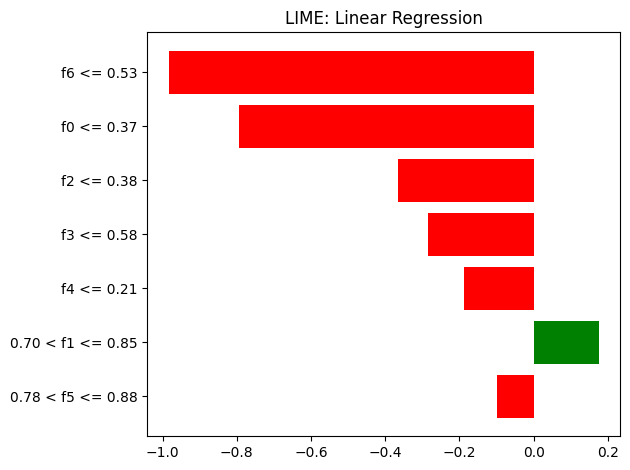

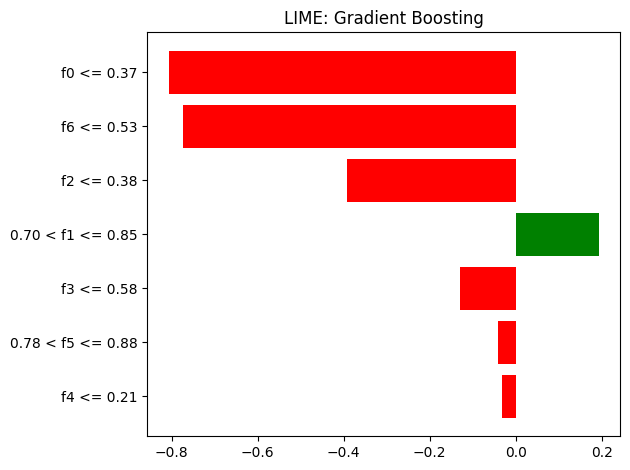

In [47]:
from lime.lime_tabular import LimeTabularExplainer

kernel_width = np.sqrt(len(features)) * 0.75

X_train_arr = X_train_sc_minmax if isinstance(X_train_sc_minmax, np.ndarray) else X_train_sc_minmax.values
X_test_arr = X_test_sc_minmax if isinstance(X_test_sc_minmax, np.ndarray) else X_test_sc_minmax.values

explainer = LimeTabularExplainer(
    training_data=X_train_arr,
    feature_names=features,
    class_names=['Ladder score'],
    mode='regression',
    kernel_width=kernel_width,
    random_state=42
)

idx = 7

exp_lr = explainer.explain_instance(
    data_row=X_test_arr[idx], 
    predict_fn=lr_minmax.predict, 
    num_features=len(features))

exp_gb = explainer.explain_instance(
    data_row=X_test_arr[idx], 
    predict_fn=gb_minmax.predict, 
    num_features=len(features))

fig_lr = exp_lr.as_pyplot_figure()
plt.title('LIME: Linear Regression')
plt.tight_layout()
plt.show()

fig_gb = exp_gb.as_pyplot_figure()
plt.title('LIME: Gradient Boosting')
plt.tight_layout()
plt.show()

Если посмотреть на графики LIME и вспомнить результаты SHAP для этого же седьмого объекта, можно заметить, что они рассказывают одну и ту же историю. Суть LIME в том, что он берет нашу конкретную точку, немного шумит вокруг нее данными и обучает на этой окрестности простую линейную регрессию, чтобы понять локальное поведение сложной модели.

На графике для линейной регрессии LIME показывает в аналогичнцую картину, что и SHAP. 

А вот на графике для градиентного бустинга мы видим усиленный эффект от признака. В итоге для нашей страны результаты LIME и SHAP получились очень похожеми по смыслу. Оба метода показали базовые независимые вклады для первой модели и смогли найти контекстную зависимость для бустинга. Разница лишь в том, что SHAP более строгий, а LIME работает быстрее и строит лишь приближенную картину, которая очень сильно зависит от правильно подобранной ширины ядра. 

### **Задание 12. (1 балл)**

Теперь сделаем LIME собственноручно. Ваша реализация должна:

- Принимать на вход точку `x0`
- Вокруг этой точки данных сэмплировать окрестность заданного размера `n`
- На данных из этой окрестности получать прогнозы объясняемой модели (учитывать веса объектов, используя ядро)
- Обучать LIME модель в виде стандартной линейной регрессии
- Возвращать коэффициенты локальной модели


Для своей реализации оцените устойчивость. Как влияет на коэффициенты количество сгенерированных точек? А выбор ядра?

**В реализации вам может помочь библиотека `fatf`**
**Свой LIME тестируйте только для бустинга.**

In [49]:
def custom_lime(model, x0, X_train, n_samples=1000, kernel_width=None):
    if isinstance(X_train, pd.DataFrame):
        X_train = X_train.values
    if isinstance(x0, pd.Series):
        x0 = x0.values

    std = np.std(X_train, axis=0)
    noise = np.random.normal(0, std, size=(n_samples, X_train.shape[1]))
    X_sampled = x0 + noise
    X_sampled[0] = x0 

    y_sampled = model.predict(X_sampled)

    if kernel_width is None:
        kernel_width = np.sqrt(X_train.shape[1]) * 0.75

    distances = pairwise_distances(X_sampled, x0.reshape(1, -1), metric='euclidean').flatten()
    weights = np.exp(-(distances ** 2) / (kernel_width ** 2))

    local_model = LinearRegression()
    local_model.fit(X_sampled, y_sampled, sample_weight=weights)

    return local_model.coef_

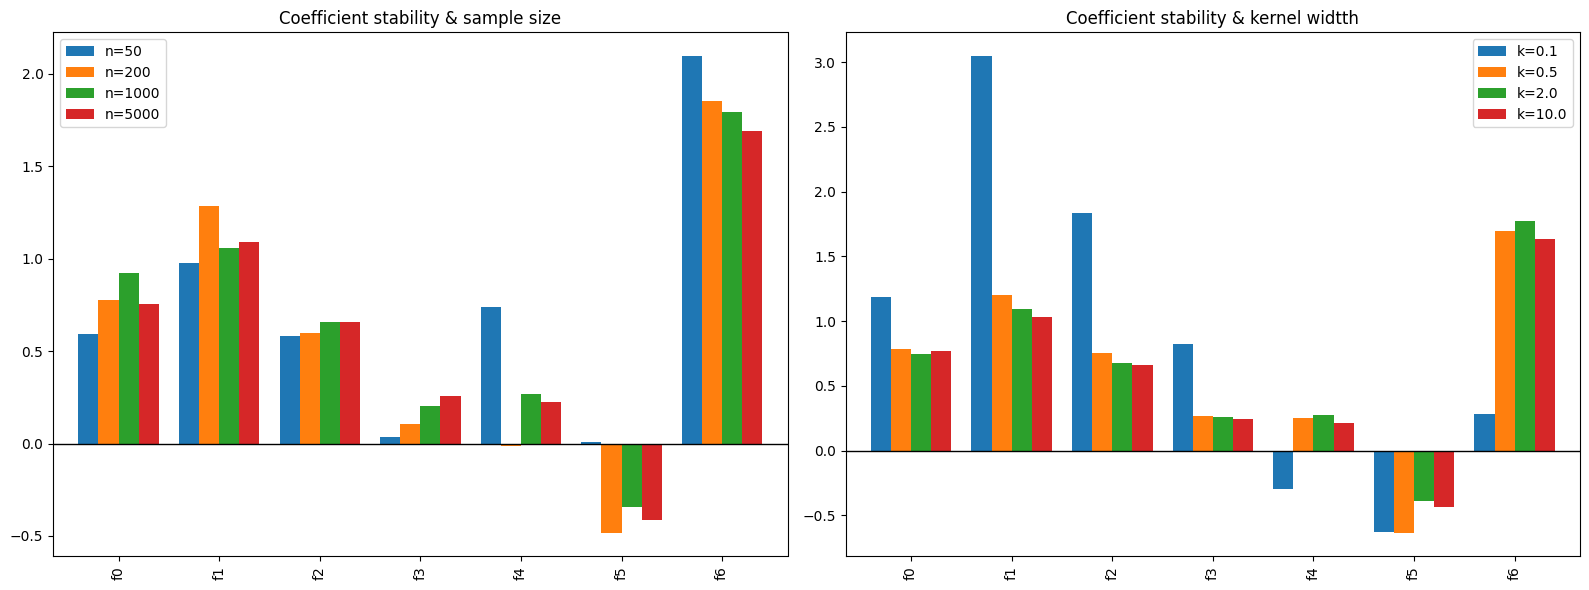

In [50]:
if hasattr(X_test_sc_minmax, 'iloc'):
    x0 = X_test_sc_minmax.iloc[idx].values
    X_train_arr = X_train_sc_minmax.values
else:
    x0 = X_test_sc_minmax[idx]
    X_train_arr = X_train_sc_minmax

n_values = [50, 200, 1000, 5000]
coefs_n = []
for n in n_values:
    coef = custom_lime(gb_minmax, x0, X_train_arr, n_samples=n)
    coefs_n.append(coef)

df_n = pd.DataFrame(coefs_n, index=[f'n={n}' for n in n_values], columns=features).T

kernel_values = [0.1, 0.5, 2.0, 10.0]
coefs_k = []
for k in kernel_values:
    coef = custom_lime(gb_minmax, x0, X_train_arr, n_samples=1000, kernel_width=k)
    coefs_k.append(coef)

df_k = pd.DataFrame(coefs_k, index=[f'k={k}' for k in kernel_values], columns=features).T

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df_n.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Coefficient stability & sample size')
axes[0].axhline(0, color='black', linewidth=1)

df_k.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Coefficient stability & kernel widtth')
axes[1].axhline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

 **Ваш вывод здесь:**

 Можно осознать что медот LIME чувствителен к настройкам. На левом графике, где мы меняли размер выборки,  видно, что при генерации всего 50 или 200 точек коэффициенты скачут и выдают менее адекватные значения. Это кажется происходит из-за того, что локальная линейная регрессия переобучается на случайном шуме. Зато когда мы увеличиваем число сгенерированных точек до тысячи или пяти тысяч, столбцы успокаиваются и начинают падать. 

Второй график при слишком маленьком ядре, равном 0.1, синие столбцы сильно растут в силу того что мы смотрим на окрестность точки. Скорее всего, бустинг в этой крошечной зоне выдает константные предсказания или имеет один резкий сплит. С другой стороны, если взять ядро равное десяти, то штраф за расстояние начинает пропадать. Наш LIME начинает захватывать слишком далекие точки и превращается из локального объяснения в глобальную аппроксимацию, сглаживая все интересные нелинейные особенности бустинга вокруг нашего конкретного объекта.

## **Вы проделали огромную работу! Ура!**